## Linear Regression Practical Implementation


In [5]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt


In [7]:
df = fetch_california_housing()

In [9]:
dataset = pd.DataFrame(df.data)

In [13]:
dataset.columns = df.feature_names
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
## Independent features and dependent features
X= dataset
y = df.target

In [16]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [17]:
## Test train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [18]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
5088,0.9809,19.0,3.187726,1.129964,726.0,2.620939,33.98,-118.28
17096,4.2232,33.0,6.189696,1.086651,1015.0,2.377049,37.46,-122.23
5617,3.5488,42.0,4.821577,1.095436,1044.0,4.331950,33.79,-118.26
20060,1.6469,24.0,4.274194,1.048387,1686.0,4.532258,35.87,-119.26
895,3.9909,14.0,4.608303,1.089350,2738.0,2.471119,37.54,-121.96
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [19]:
## Standardizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)

array([[-1.52169954, -0.75868455, -0.91813082, ..., -0.04014979,
        -0.78315293,  0.65090402],
       [ 0.18205382,  0.3523991 ,  0.30748451, ..., -0.05943619,
         0.8475975 , -1.31911678],
       [-0.17232772,  1.06666717, -0.25107784, ...,  0.09515433,
        -0.87218816,  0.66087881],
       ...,
       [-0.49518065,  0.59048846, -0.59192622, ...,  0.01608523,
        -0.75972261,  0.60103008],
       [ 0.96816708, -1.07613702,  0.39144665, ...,  0.0039722 ,
         0.90383028, -1.18445713],
       [-0.68377427,  1.86029835, -0.83041358, ..., -0.08065717,
         0.9928655 , -1.41387727]], shape=(13828, 8))

In [21]:
X_test = scaler.transform(X_train)

In [22]:
scaler.inverse_transform(X_train)

array([[   5.74343117,  267.96557738,   13.24443535, ...,   36.2721907 ,
         108.16411141, -356.74300046],
       [  11.91363721,  444.3699364 ,   20.59733246, ...,   33.18804467,
         115.59038567, -364.6629676 ],
       [  10.63023131,  557.77273863,   17.24632064, ...,   57.9090824 ,
         107.75865391, -356.70289936],
       ...,
       [   9.46100743,  482.17087048,   15.20145139, ...,   45.26490362,
         108.27081076, -356.94350596],
       [  14.76057557,  217.56433194,   21.10105086, ...,   43.32787198,
         115.84646409, -364.12160276],
       [   8.77800865,  683.77585222,   13.77068188, ...,   29.7945339 ,
         116.2519216 , -365.04392805]], shape=(13828, 8))

In [23]:
from sklearn.linear_model import LinearRegression
##cross validation
from sklearn.model_selection import cross_val_score

In [35]:
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
mse = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=5)

In [37]:
np.mean(mse)

np.float64(-0.5230499763383932)

In [38]:
##Prediction
reg_pred = regression.predict(X_test)

d:\ML-in-python\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [39]:
reg_pred

array([-37.55169703, -36.83661457, -37.04316688, ..., -37.19817412,
       -36.6256598 , -37.13699424], shape=(13828,))

In [44]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


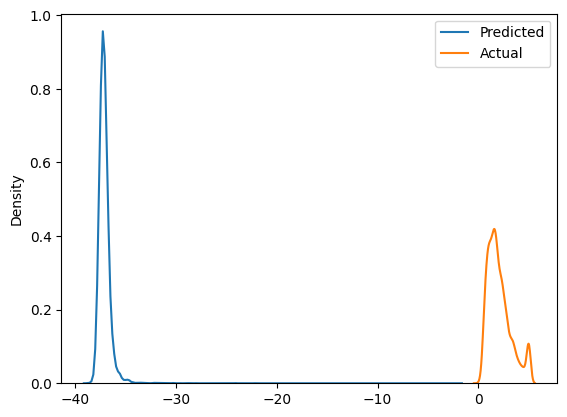

In [57]:
import seaborn as sns
# sns.displot(reg_pred,y_test,kind='kde')
import matplotlib.pyplot as plt

sns.kdeplot(reg_pred, label="Predicted")
sns.kdeplot(y_test, label="Actual")

plt.legend()
plt.show()

In [58]:
from sklearn.metrics import r2_score

In [59]:
score=r2_score(reg_pred, y_test)
score

ValueError: Found input variables with inconsistent numbers of samples: [13828, 6812]